
# Блок 3. Продвинутый уровень. Занятие 15

# Финансовый анализ и прогнозирование

## Теория

Сегодня изучаем основы финансовой аналитики на реальном датасете.

Будем использовать открытый датасет фондового рынка S&P500:

https://raw.githubusercontent.com/datasets/s-and-p-500/master/data/data.csv

### Описание колонок

| Колонка | Описание |
|----------|----------|
| Date | дата торгов |
| SP500 | значение индекса S&P500 |

S&P500 — один из самых известных фондовых индексов мира.

---

## Что будем делать

- загружать финансовые данные;
- строить временные ряды;
- вычислять изменения;
- строить скользящее среднее;
- делать простой прогноз;
- анализировать тренды.

---

## Практическое применение

Похожие задачи используются:

- в банках;
- инвестиционных компаниях;
- бизнес-аналитике;
- прогнозировании продаж;
- анализе прибыли компаний.

---

## Связь с дипломом

Такие методы пригодятся:

- анализ продаж;
- анализ выручки;
- анализ клиентов;
- анализ недвижимости;
- анализ тренировок;
- анализ питания.


Сначала изучите SOLVED-ноутбук, затем выполните TODO самостоятельно.

## Ячейка 1. TODO: импорт библиотек

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

assert pd is not None


## Ячейка 2. TODO: загрузите финансовый датасет

In [ ]:
file_path = r"..\..\data\daily_nutrition.csv"

df = pd.read_csv(file_path, nrows=100)

display(df.head())

assert len(df) == 100



,user_id,diary_date,calories,carbs,fat,protein,sodium,sugar,goal_calories,goal_carbs,goal_fat,goal_protein,goal_sodium,goal_sugar
0,1,2014-09-14,2924.0,340.0,114.0,186.0,3658.0,109.0,3173.0,396.0,105.0,160.0,2300.0,119.0
1,1,2014-09-15,2430.0,96.0,37.0,50.0,855.0,63.0,1572.0,196.0,52.0,79.0,2300.0,59.0
2,1,2014-09-16,1862.0,158.0,54.0,114.0,2215.0,100.0,1832.0,229.0,61.0,92.0,2300.0,69.0
3,1,2014-09-17,2251.0,187.0,60.0,98.0,1765.0,105.0,1685.0,210.0,56.0,85.0,2300.0,63.0
4,1,2014-09-18,2001.0,113.0,81.0,202.0,1101.0,71.0,1597.0,199.0,53.0,80.0,2300.0,60.0


## Ячейка 3. TODO: изучите структуру данных

In [ ]:
import pandas as pd


def get_user_with_max_records(file_path):
    """
    Находит пользователя с максимальным числом записей в файле
    и возвращает DataFrame только с его данными.
    """
    # Первый проход: подсчёт количества записей для каждого user_id
    chunk_iter = pd.read_csv(file_path, chunksize=50000, usecols=["user_id"])

    user_counts = {}
    for chunk in chunk_iter:

        counts = chunk["user_id"].value_counts().to_dict()
        for uid, cnt in counts.items():
            user_counts[uid] = user_counts.get(uid, 0) + cnt

    if not user_counts:
        raise ValueError("Файл пуст или не содержит колонки user_id")

    target_user = max(user_counts, key=user_counts.get)
    max_records = user_counts[target_user]
    print(f"Выбран пользователь {target_user} с {max_records} записями (максимум)")

    chunk_iter = pd.read_csv(
        file_path,
        chunksize=50000,
        usecols=["user_id", "diary_date", "calories", "protein", "fat", "carbs"],
    )
    user_data = []
    for chunk in chunk_iter:
        filtered = chunk[chunk["user_id"] == target_user]
        if not filtered.empty:
            user_data.append(filtered)

    df_user = pd.concat(user_data, ignore_index=True)
    return df_user


# в датасете несколько пользователей, берем одного с максимальным количеством записей.
df = get_user_with_max_records(file_path)
print("Размер загруженных данных:", df.shape)
display(df.head())


print(df.shape)
print(df.columns.tolist())

df.info()


Выбран пользователь 4293 с 187 записями (максимум)
Размер загруженных данных: (187, 6)


,user_id,diary_date,calories,carbs,fat,protein
0,4293,2014-09-26,1467.0,180.0,41.0,104.0
1,4293,2014-09-27,1641.0,172.0,46.0,147.0
2,4293,2014-09-28,1593.0,180.0,56.0,110.0
3,4293,2014-09-29,1633.0,187.0,43.0,131.0
4,4293,2014-09-30,1514.0,165.0,40.0,117.0


(187, 6)
['user_id', 'diary_date', 'calories', 'carbs', 'fat', 'protein']
<class 'pandas.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   user_id     187 non-null    int64  
 1   diary_date  187 non-null    str    
 2   calories    187 non-null    float64
 3   carbs       187 non-null    float64
 4   fat         187 non-null    float64
 5   protein     187 non-null    float64
dtypes: float64(4), int64(1), str(1)
memory usage: 8.9 KB


## Ячейка 4. TODO: преобразуйте дату

In [131]:
df["Date"] = pd.to_datetime(df["diary_date"])

print(df.dtypes)

assert str(df["Date"].dtype).startswith("datetime")


user_id                int64
diary_date               str
calories             float64
carbs                float64
fat                  float64
protein              float64
Date          datetime64[us]
dtype: object


## Ячейка 5. TODO: постройте график индекса

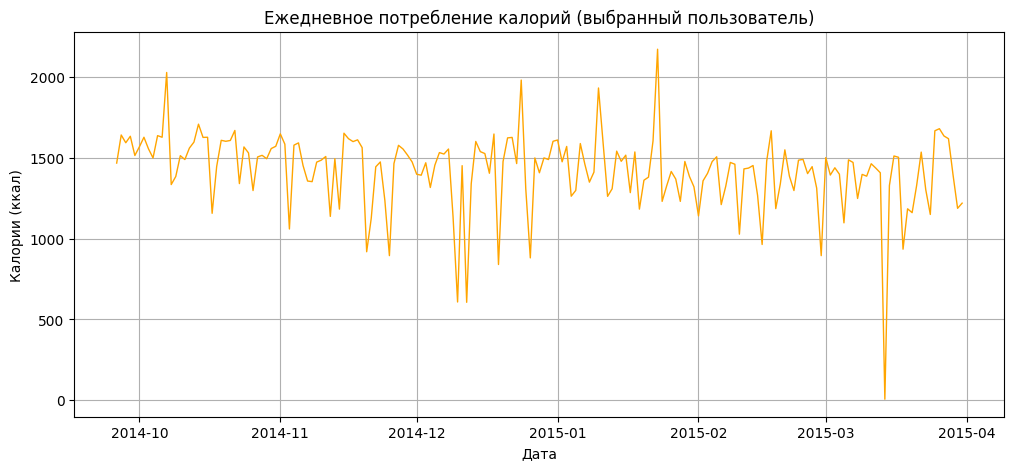

In [132]:
# plt.figure(figsize=(12, 5))
# plt.plot(df["Date"], df["calories"])

# plt.title("S&P500")
# plt.grid(True)
# plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["calories"], color="orange", linewidth=1)
plt.title("Ежедневное потребление калорий (выбранный пользователь)")
plt.xlabel("Дата")
plt.ylabel("Калории (ккал)")
plt.grid(True)
plt.show()

## Ячейка 6. TODO: вычислите изменения индекса

In [133]:
df["delta_calories"] = df["calories"].diff()
print("Первые строки с изменениями:")
display(df[["Date", "calories", "delta_calories"]].head(10))


Первые строки с изменениями:


,Date,calories,delta_calories
0,2014-09-26,1467.0,NaN
1,2014-09-27,1641.0,174.0
2,2014-09-28,1593.0,-48.0
3,2014-09-29,1633.0,40.0
4,2014-09-30,1514.0,-119.0
5,2014-10-01,1568.0,54.0
6,2014-10-02,1627.0,59.0
7,2014-10-03,1555.0,-72.0
8,2014-10-04,1499.0,-56.0
9,2014-10-05,1637.0,138.0


## Ячейка 7. TODO: создайте скользящее среднее

In [134]:
df["ma7"] = df["calories"].rolling(window=7).mean()

display(df.head(40))

assert "ma7" in df.columns


,user_id,diary_date,calories,carbs,fat,protein,Date,delta_calories,ma7
0,4293,2014-09-26,1467.0,180.0,41.0,104.0,2014-09-26,NaN,NaN
1,4293,2014-09-27,1641.0,172.0,46.0,147.0,2014-09-27,174.0,NaN
2,4293,2014-09-28,1593.0,180.0,56.0,110.0,2014-09-28,-48.0,NaN
3,4293,2014-09-29,1633.0,187.0,43.0,131.0,2014-09-29,40.0,NaN
4,4293,2014-09-30,1514.0,165.0,40.0,117.0,2014-09-30,-119.0,NaN
5,4293,2014-10-01,1568.0,180.0,41.0,116.0,2014-10-01,54.0,NaN
6,4293,2014-10-02,1627.0,175.0,46.0,126.0,2014-10-02,59.0,1577.571429
7,4293,2014-10-03,1555.0,174.0,33.0,140.0,2014-10-03,-72.0,1590.142857
8,4293,2014-10-04,1499.0,185.0,49.0,110.0,2014-10-04,-56.0,1569.857143
9,4293,2014-10-05,1637.0,182.0,47.0,126.0,2014-10-05,138.0,1576.142857


## Ячейка 8. TODO: постройте сравнительный график

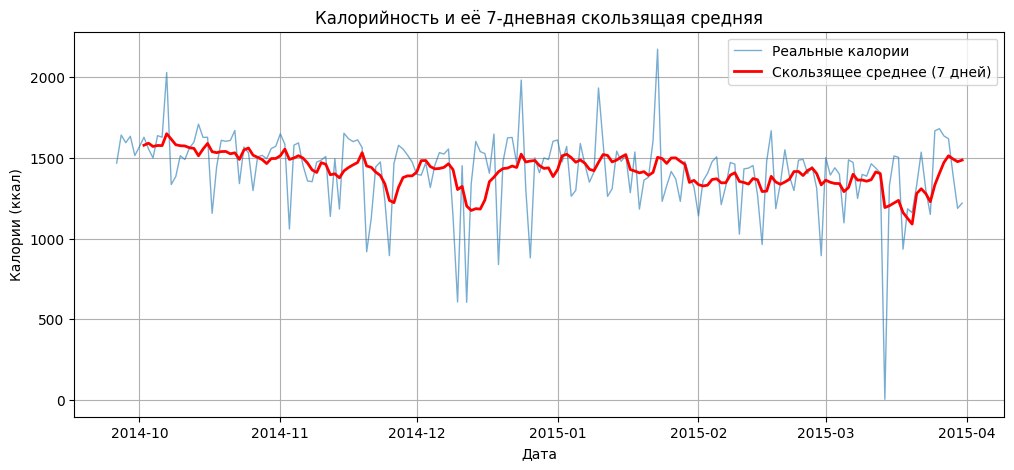

In [135]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["calories"], label="Реальные калории", alpha=0.6, linewidth=1)
plt.plot(
    df["Date"], df["ma7"], label="Скользящее среднее (7 дней)", color="red", linewidth=2
)
plt.title("Калорийность и её 7-дневная скользящая средняя")
plt.xlabel("Дата")
plt.ylabel("Калории (ккал)")
plt.legend()
plt.grid(True)
plt.show()


## Ячейка 9. TODO: сделайте простой прогноз

In [136]:
forecast = df["calories"].tail(30).mean()

print("Прогноз:", forecast)

assert forecast > 0


Прогноз: 1332.0666666666666


## Ячейка 10. TODO: сформируйте отчет и assert

In [137]:
report = {
    "rows": len(df),
    "min": df["calories"].min(),
    "max": df["calories"].max(),
    "mean": df["calories"].mean(),
    "forecast": forecast,
}

for k, v in report.items():
    print(k, ":", v)

assert report["rows"] > 100


rows : 187
min : 5.0
max : 2172.0
mean : 1421.0748663101604
forecast : 1332.0666666666666
